In [1]:
import os

ucl_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL"

for root, dirs, files in os.walk(ucl_path):
    level = root.replace(ucl_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    sub_indent = '  ' * (level + 1)
    for f in sorted(files)[:10]:  # first 10 files per folder
        size_kb = os.path.getsize(os.path.join(root, f)) // 1024
        print(f"{sub_indent}📄 {f}  ({size_kb} KB)")
    if len(files) > 10:
        print(f"{sub_indent}... and {len(files)-10} more files")

📁 UCL/
  📁 Database/
    📄 (1) Infant Demographics.xlsx  (68 KB)
    📄 (2) Study details.xlsx  (31 KB)
    📄 (3) Stimulation information.xlsx  (65 KB)
    📄 (4) Infant patient notes.xlsx  (189 KB)
    📄 (5) Maternal patient notes.xlsx  (18 KB)
  📁 EEG/
    📁 2510001/
      📄 2510001A01.mat  (596 KB)
      📄 2510001C01.mat  (596 KB)
      📄 2510001L01.mat  (7374 KB)
    📁 2510101/
      📄 2510101A01.mat  (625 KB)
      📄 2510101C01.mat  (625 KB)
      📄 2510101L01.mat  (7818 KB)
    📁 2510201/
      📄 2510201A01.mat  (605 KB)
      📄 2510201C01.mat  (609 KB)
      📄 2510201L01.mat  (7765 KB)
    📁 2510301/
      📄 2510301A01.mat  (625 KB)
      📄 2510301C01.mat  (626 KB)
      📄 2510301L01.mat  (7202 KB)
    📁 2510401/
      📄 2510401A01.mat  (627 KB)
      📄 2510401C01.mat  (631 KB)
      📄 2510401L01.mat  (7717 KB)
    📁 2510501/
      📄 2510501A01.mat  (546 KB)
      📄 2510501C01.mat  (550 KB)
      📄 2510501L01.mat  (6750 KB)
    📁 2510601/
      📄 2510601A01.mat  (643 KB)
      📄 2

In [2]:
import scipy.io
import numpy as np
import pandas as pd
import os

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"
db_path      = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\Database"

# ── STEP 1: Correctly load one .mat file ─────────────────────────────
mat = scipy.io.loadmat(
    f"{ucl_eeg_path}\\2510001\\2510001L01.mat",
    squeeze_me=True,
    struct_as_record=False
)
eeg = mat['EEG']

print("=" * 50)
print("SINGLE .MAT FILE INSPECTION")
print("=" * 50)
print(f"Subject       : {eeg.subject}")
print(f"Condition     : {eeg.condition}")
print(f"Sampling rate : {eeg.srate} Hz")
print(f"Channels      : {eeg.nbchan}")
print(f"Time points   : {eeg.pnts}")
print(f"Duration      : {eeg.pnts / eeg.srate:.1f} seconds")
print(f"EEG data shape: {eeg.data.shape}")
print(f"Time axis     : {eeg.times[0]:.3f}s to {eeg.times[-1]:.3f}s")

# Channel names
try:
    ch_names = [str(eeg.chanlocs[i].labels) for i in range(len(eeg.chanlocs))]
    print(f"Channel names : {ch_names}")
except Exception as ex:
    print(f"Channel names : could not parse — {ex}")

# other_data — HR and SpO2 pre-computed values
print(f"\nother_data type  : {type(eeg.other_data)}")
try:
    od = eeg.other_data
    if hasattr(od, 'dtype') and od.dtype.names:
        print(f"other_data fields: {od.dtype.names}")
        for name in od.dtype.names:
            print(f"  {name}: {od[name]}")
    else:
        print(f"other_data shape : {od.shape}")
        print(f"other_data value : {od}")
except Exception as ex:
    print(f"other_data error : {ex}")


SINGLE .MAT FILE INSPECTION
Subject       : 25100
Condition     : lance
Sampling rate : 2000 Hz
Channels      : 18
Time points   : 8000
Duration      : 4.0 seconds
EEG data shape: (18, 8000)
Time axis     : -2000.000s to 1999.500s
Channel names : ['Cz', 'CPz', 'F8', 'T8', 'TP10', 'P8', 'O2', 'F4', 'C4', 'CP4', 'F7', 'T7', 'TP9', 'P7', 'O1', 'F3', 'C3', 'CP3']

other_data type  : <class 'scipy.io.matlab._mio5_params.mat_struct'>
other_data error : 'mat_struct' object has no attribute 'shape'


In [3]:
import pandas as pd

db_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\Database"

# File 1 — all sheets
xl1 = pd.ExcelFile(f"{db_path}\\(1) Infant Demographics.xlsx")
print("File 1 sheets:", xl1.sheet_names)

# File 2 — all sheets
xl2 = pd.ExcelFile(f"{db_path}\\(2) Study details.xlsx")
print("File 2 sheets:", xl2.sheet_names)

# File 3 — all sheets (3 tabs)
xl3 = pd.ExcelFile(f"{db_path}\\(3) Stimulation information.xlsx")
print("File 3 sheets:", xl3.sheet_names)

# File 4 — all sheets
xl4 = pd.ExcelFile(f"{db_path}\\(4) Infant patient notes.xlsx")
print("File 4 sheets:", xl4.sheet_names)

# File 5 — all sheets
xl5 = pd.ExcelFile(f"{db_path}\\(5) Maternal patient notes.xlsx")
print("File 5 sheets:", xl5.sheet_names)

File 1 sheets: ['Demographics', 'Delivery details', 'SNAP scores']
File 2 sheets: ['Study context', 'EEG details']
File 3 sheets: ['Heel lance', 'Sham control', 'Auditory control']
File 4 sheets: ['Ventilation', 'Diagnosis', 'Cranial scans', 'Medication', 'Heel lances', 'Painful procedures', 'Injuries']
File 5 sheets: ['Maternal']


## Next_Cell -- loads all 3 condition sheets from the stimulation Excel, stacks them into one big table, adds pain labels, adds gestational age from demographics, flags infants on analgesics from the medication sheet, builds the file path for each recording, checks which files actually exist on disk, and saves everything as ucl_master_labels.csv.

MASTER LABEL TABLE SUMMARY
Total records      : 310
Files found        : 308
Files missing      : 2

Condition counts:
condition
lance       112
sham         99
auditory     99

PIPP pain/no-pain (where available):
pipp_label
0.0    169
NaN     95
1.0     46

Age groups:
age_group
G3_oldest      199
G1_youngest     78
G2_middle       33

On analgesics: 3 infants

Sample lance rows with PIPP:
    Record identifier EEG file name condition  pain_label  Total PIPP score  pipp_label  Gestational age at birth (weeks)  age_group  on_analgesic  Baseline heart rate (bmp)  Max heart rate (bpm)  Baseline O2 sats  Min O2 sats  file_exists
10             254101     254101L01     lance           1              11.0         1.0                         35.714286  G3_oldest             0                      135.0                 159.0              97.0         96.0         True
11             254401     254401L01     lance           1              17.0         1.0                         37.000000  G3

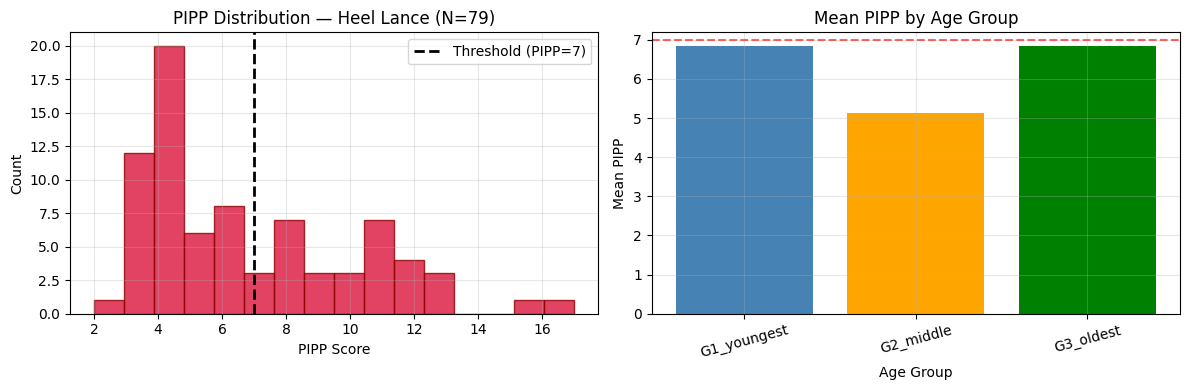


✅ Saved ucl_master_labels.csv — 310 rows


In [4]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"
db_path      = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\Database"
save_path    = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"

# Load all 3 condition sheets from stimulation Excel
# header=1 because row 0 is a merged title, row 1 has real column names
lance_df    = pd.read_excel(f"{db_path}\\(3) Stimulation information.xlsx",
                             sheet_name='Heel lance',       header=1)
sham_df     = pd.read_excel(f"{db_path}\\(3) Stimulation information.xlsx",
                             sheet_name='Sham control',     header=1)
auditory_df = pd.read_excel(f"{db_path}\\(3) Stimulation information.xlsx",
                             sheet_name='Auditory control', header=1)

# Label each condition
lance_df['condition']    = 'lance';    lance_df['pain_label']    = 1
sham_df['condition']     = 'sham';     sham_df['pain_label']     = 0
auditory_df['condition'] = 'auditory'; auditory_df['pain_label'] = 0

# Stack all 3 into one table
master = pd.concat([lance_df, sham_df, auditory_df], ignore_index=True)

# PIPP-based refined label
pipp_col = 'Total PIPP score'
master['pipp_label'] = master[pipp_col].apply(
    lambda x: 1 if pd.notna(x) and x >= 7
              else (0 if pd.notna(x) else np.nan)
)

# Add gestational age from demographics sheet
demo_df = pd.read_excel(f"{db_path}\\(1) Infant Demographics.xlsx",
                         sheet_name='Demographics', header=0)
ga_col = 'Gestational age at birth (weeks)'
master = master.merge(demo_df[['Record identifier', ga_col]],
                      on='Record identifier', how='left')

# Assign age group (matches Hamwi 2025 grouping — our baseline paper)
def age_group(ga):
    if pd.isna(ga):    return 'unknown'
    if ga <= 31.857:   return 'G1_youngest'
    if ga <= 33.857:   return 'G2_middle'
    return                    'G3_oldest'

master['age_group'] = master[ga_col].apply(age_group)

# Flag infants on analgesics — they have blunted pain response
meds_df = pd.read_excel(f"{db_path}\\(4) Infant patient notes.xlsx",
                         sheet_name='Medication', header=1)
meds_df.rename(columns={meds_df.columns[0]: 'Record identifier'}, inplace=True)
meds_df['on_analgesic'] = meds_df.iloc[:, 3].notna().astype(int)
master = master.merge(meds_df[['Record identifier', 'on_analgesic']],
                      on='Record identifier', how='left')
master['on_analgesic'] = master['on_analgesic'].fillna(0).astype(int)

# Build file path for each row and check if file exists
def build_path(row):
    fname = str(row['EEG file name']).strip()
    # Find folder: all characters up to the condition letter (A, C, or L)
    import re
    match = re.match(r'^(\d+)[ACL]', fname)
    folder = match.group(1) if match else fname[:7]
    return f"{ucl_eeg_path}\\{folder}\\{fname}.mat"

master['mat_path']    = master.apply(build_path, axis=1)
master['file_exists'] = master['mat_path'].apply(os.path.exists)

# Print summary
print("=" * 50)
print("MASTER LABEL TABLE SUMMARY")
print("=" * 50)
print(f"Total records      : {len(master)}")
print(f"Files found        : {master['file_exists'].sum()}")
print(f"Files missing      : {(~master['file_exists']).sum()}")
print(f"\nCondition counts:")
print(master['condition'].value_counts().to_string())
print(f"\nPIPP pain/no-pain (where available):")
print(master['pipp_label'].value_counts(dropna=False).to_string())
print(f"\nAge groups:")
print(master['age_group'].value_counts().to_string())
print(f"\nOn analgesics: "
      f"{master.drop_duplicates('Record identifier')['on_analgesic'].sum()} infants")

# Show sample rows
show = ['Record identifier','EEG file name','condition','pain_label',
        pipp_col,'pipp_label',ga_col,'age_group','on_analgesic',
        'Baseline heart rate (bmp)','Max heart rate (bpm)',
        'Baseline O2 sats','Min O2 sats','file_exists']
show = [c for c in show if c in master.columns]
print(f"\nSample lance rows with PIPP:")
print(master[(master['condition']=='lance') &
             master[pipp_col].notna()][show].head(6).to_string())

# PIPP distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ldf = master[(master['condition']=='lance') & master[pipp_col].notna()]
axes[0].hist(ldf[pipp_col], bins=16, color='crimson',
             alpha=0.8, edgecolor='darkred')
axes[0].axvline(x=7, color='black', linestyle='--',
                linewidth=2, label='Threshold (PIPP=7)')
axes[0].set_title(f'PIPP Distribution — Heel Lance (N={len(ldf)})')
axes[0].set_xlabel('PIPP Score')
axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

age_mean = ldf.groupby('age_group')[pipp_col].mean().sort_index()
axes[1].bar(age_mean.index, age_mean.values,
            color=['steelblue','orange','green'][:len(age_mean)])
axes[1].axhline(y=7, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Mean PIPP by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Mean PIPP')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\ucl_pipp_overview.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Save
master[show].to_csv(f"{save_path}\\ucl_master_labels.csv", index=False)
print(f"\n✅ Saved ucl_master_labels.csv — {len(master)} rows")

od.data raw shape : (3, 717076)
od_data after fix : (3, 8000)
recg_signal shape : (8000,)
resp_signal shape : (8000,)
times shape       : (8000,)


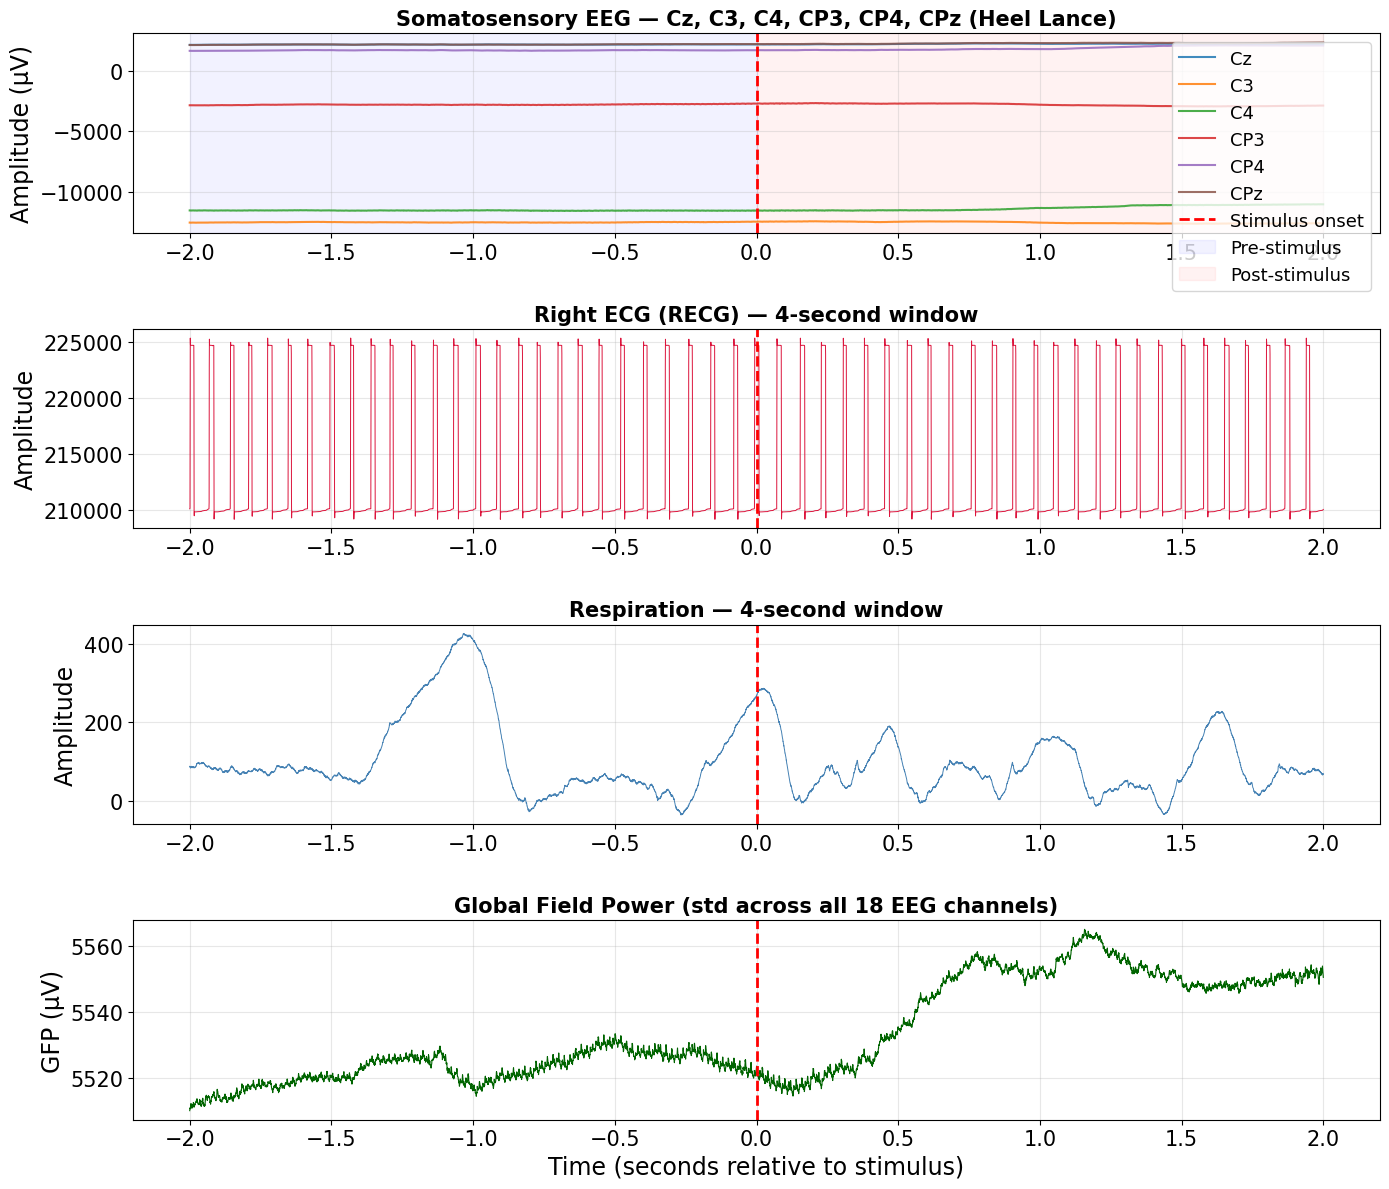

In [6]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"

# Load one lance file
mat = scipy.io.loadmat(
    f"{ucl_eeg_path}\\2510001\\2510001L01.mat",
    squeeze_me=True, struct_as_record=False
)
eeg = mat['EEG']

# EEG data — confirmed (18, 8000)
eeg_data = eeg.data
times    = eeg.times / 1000   # ms → seconds, gives -2.0 to +1.9995
srate    = eeg.srate           # 2000 Hz

# ── Fix: access other_data correctly ──────────────────────────────────
# od.data with squeeze_me returns the raw MATLAB array — need direct attribute
od = eeg.other_data
# od._fieldnames confirmed as ['data', 'labels']
# od.data is the raw signal, but may be full-length — slice to 8000 points
raw_od = od.data
print(f"od.data raw shape : {raw_od.shape}")

# Slice to match EEG window: take first 3 rows, first 8000 columns
if raw_od.ndim == 2:
    if raw_od.shape[1] >= 8000:
        od_data = raw_od[:3, :8000]   # (3, 8000): RECG, LECG, Resp
    else:
        od_data = raw_od[:3, :]
elif raw_od.ndim == 1:
    od_data = raw_od.reshape(3, -1)[:, :8000]

print(f"od_data after fix : {od_data.shape}")  # must be (3, 8000)

recg_signal = od_data[0]   # Right ECG
resp_signal = od_data[2]   # Respiration

print(f"recg_signal shape : {recg_signal.shape}")   # must be (8000,)
print(f"resp_signal shape : {resp_signal.shape}")   # must be (8000,)
print(f"times shape       : {times.shape}")          # must be (8000,)

# Channel names
ch_names = [str(eeg.chanlocs[i].labels) for i in range(len(eeg.chanlocs))]

# Somatosensory channels most relevant for pain
soma_channels = ['Cz', 'C3', 'C4', 'CP3', 'CP4', 'CPz']
soma_idx = [ch_names.index(c) for c in soma_channels if c in ch_names]

# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

TITLE_SIZE  = 15
LABEL_SIZE  = 17
TICK_SIZE   = 15
LEGEND_SIZE = 13

# Plot 1: Somatosensory EEG
for ch_i in soma_idx:
    axes[0].plot(times, eeg_data[ch_i],
                 linewidth=1.5, label=ch_names[ch_i], alpha=0.85)

axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Stimulus onset')
axes[0].axvspan(-2, 0, alpha=0.05, color='blue', label='Pre-stimulus')
axes[0].axvspan(0, 2, alpha=0.05, color='red', label='Post-stimulus')

axes[0].set_title('Somatosensory EEG — Cz, C3, C4, CP3, CP4, CPz (Heel Lance)',
                  fontsize=TITLE_SIZE, fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)', fontsize=LABEL_SIZE)

axes[0].tick_params(axis='both', labelsize=TICK_SIZE)
axes[0].legend(loc='upper right', fontsize=LEGEND_SIZE)
axes[0].grid(True, alpha=0.3)

# Plot 2: Right ECG
axes[1].plot(times, recg_signal, color='crimson', linewidth=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[1].set_title('Right ECG (RECG) — 4-second window',
                  fontsize=TITLE_SIZE, fontweight='bold')
axes[1].set_ylabel('Amplitude', fontsize=LABEL_SIZE)

axes[1].tick_params(axis='both', labelsize=TICK_SIZE)
axes[1].grid(True, alpha=0.3)

# Plot 3: Respiration
axes[2].plot(times, resp_signal, color='steelblue', linewidth=0.7)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[2].set_title('Respiration — 4-second window',
                  fontsize=TITLE_SIZE, fontweight='bold')
axes[2].set_ylabel('Amplitude', fontsize=LABEL_SIZE)

axes[2].tick_params(axis='both', labelsize=TICK_SIZE)
axes[2].grid(True, alpha=0.3)

# Plot 4: Global Field Power
gfp = np.std(eeg_data, axis=0)
axes[3].plot(times, gfp, color='darkgreen', linewidth=0.8)
axes[3].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[3].set_title('Global Field Power (std across all 18 EEG channels)',
                  fontsize=TITLE_SIZE, fontweight='bold')
axes[3].set_ylabel('GFP (μV)', fontsize=LABEL_SIZE)
axes[3].set_xlabel('Time (seconds relative to stimulus)', fontsize=LABEL_SIZE)

axes[3].tick_params(axis='both', labelsize=TICK_SIZE)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    r"C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\ucl_single_file_signals_new.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [6]:
import scipy.io
import numpy as np
import pandas as pd
from scipy import signal as sp_signal
import neurokit2 as nk
import os
import re
import warnings
warnings.filterwarnings('ignore')

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"
save_path    = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"

master = pd.read_csv(f"{save_path}\\ucl_master_labels.csv")

def rebuild_path(eeg_fname):
    fname  = str(eeg_fname).strip()
    match  = re.match(r'^(\d+)[ACL]', fname)
    folder = match.group(1) if match else fname[:7]
    return f"{ucl_eeg_path}\\{folder}\\{fname}.mat"

master['mat_path']    = master['EEG file name'].apply(rebuild_path)
master['file_exists'] = master['mat_path'].apply(os.path.exists)
master = master[master['file_exists'] == True].reset_index(drop=True)
print(f"Files to process: {len(master)}")

# Somatosensory channels for pain — look these up dynamically per file
SOMA_CHS = ['Cz', 'CPz', 'C3', 'C4', 'CP3', 'CP4']
srate    = 2000

def bandpower(signal_1d, fs, fmin, fmax):
    n = len(signal_1d)
    if n < 50:
        return np.nan
    # Need nperseg large enough to resolve fmin frequency
    # Rule: nperseg >= 2 * fs / fmin gives at least 2 cycles of the lowest frequency
    nperseg = min(n, max(512, int(fs / fmin) * 2))
    nperseg = min(nperseg, n)   # never exceed signal length
    freqs, psd = sp_signal.welch(signal_1d, fs=fs, nperseg=nperseg)
    idx = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(idx):
        return np.nan
    return float(np.trapezoid(psd[idx], freqs[idx]))

def extract_features(mat_path):
    try:
        mat   = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
        eeg   = mat['EEG']
        data  = eeg.data    # (N_channels, 8000)
        times = eeg.times   # ms: -2000 to +1999.5

        # ── Get actual channel names from THIS file ────────────────────
        try:
            file_ch_names = [str(ch.labels) for ch in eeg.chanlocs]
        except Exception:
            return None   # can't read channels — skip

        # ── Find somatosensory channel indices in THIS file ────────────
        soma_idx = []
        soma_names_found = []
        for ch in SOMA_CHS:
            if ch in file_ch_names:
                soma_idx.append(file_ch_names.index(ch))
                soma_names_found.append(ch)

        if len(soma_idx) == 0:
            return None   # no somatosensory channels at all — skip

        # ── Time window indices ────────────────────────────────────────
        pre_idx      = times < 0
        post_idx     = times >= 0
        post_500_idx = (times >= 0) & (times <= 500)

        if post_idx.sum() < 10 or pre_idx.sum() < 10:
            return None

        features = {}

        # ── EEG features — only somatosensory channels found in file ──
        for ch_i, ch_name in zip(soma_idx, soma_names_found):
            sig  = data[ch_i]        # correct row for THIS file's layout
            pre  = sig[pre_idx]
            post = sig[post_idx]

            features[f'{ch_name}_delta_post'] = bandpower(post, srate, 1, 4)
            features[f'{ch_name}_theta_post'] = bandpower(post, srate, 4, 8)
            features[f'{ch_name}_alpha_post'] = bandpower(post, srate, 8, 13)
            features[f'{ch_name}_beta_post'] = bandpower(post, srate, 13, 30)

            alpha_val = features[f'{ch_name}_alpha_post']
            delta_val = features[f'{ch_name}_delta_post']
            if alpha_val and not np.isnan(alpha_val) and alpha_val > 1e-10:
                features[f'{ch_name}_delta_alpha_ratio'] = delta_val / alpha_val
            else:
                features[f'{ch_name}_delta_alpha_ratio'] = np.nan

            pre_delta  = bandpower(pre,  srate, 1, 4)
            post_delta = features[f'{ch_name}_delta_post']
            if pre_delta and not np.isnan(pre_delta) and pre_delta > 1e-10:
                features[f'{ch_name}_delta_change'] = post_delta / pre_delta
            else:
                features[f'{ch_name}_delta_change'] = np.nan

            if post_500_idx.sum() > 0:
                features[f'{ch_name}_erp_peak'] = float(np.max(np.abs(sig[post_500_idx])))
                features[f'{ch_name}_erp_mean'] = float(np.mean(sig[post_500_idx]))
            else:
                features[f'{ch_name}_erp_peak'] = np.nan
                features[f'{ch_name}_erp_mean'] = np.nan
            
            early_idx = (times >= 0) & (times <= 250)
            late_idx  = (times > 250) & (times <= 500)
            features[f'{ch_name}_erp_early'] = float(np.max(np.abs(sig[early_idx]))) if early_idx.sum() > 0 else np.nan
            features[f'{ch_name}_erp_late']  = float(np.max(np.abs(sig[late_idx])))  if late_idx.sum()  > 0 else np.nan

        # Fill missing somatosensory channels with NaN
        for ch_name in SOMA_CHS:
            for suffix in ['_delta_post','_theta_post','_alpha_post',
                           '_delta_change','_erp_peak','_erp_mean']:
                key = f'{ch_name}{suffix}'
                if key not in features:
                    features[key] = np.nan

        # ── Global Field Power ─────────────────────────────────────────
        gfp_post = np.std(data[:, post_idx], axis=0)
        features['gfp_mean_post'] = float(np.mean(gfp_post))
        features['gfp_max_post']  = float(np.max(gfp_post))

        # ── Number of channels — useful meta-feature ──────────────────
        features['n_channels'] = data.shape[0]

        # ── ECG from other_data ────────────────────────────────────────
        od     = eeg.other_data
        raw_od = od.data
        n_cols = data.shape[1]
        if raw_od.ndim == 2:
            od_full = raw_od[:3, :n_cols] if raw_od.shape[1] >= n_cols else raw_od[:3, :]
        else:
            od_full = raw_od.reshape(3, -1)[:, :n_cols]

        recg_full = od_full[0]

        try:
            recg_clean  = nk.ecg_clean(recg_full, sampling_rate=srate)
            _, info     = nk.ecg_peaks(recg_clean, sampling_rate=srate)
            rpeaks      = info['ECG_R_Peaks']
            stim_sample = np.where(times >= 0)[0][0]
            pre_peaks   = rpeaks[rpeaks < stim_sample]
            post_peaks  = rpeaks[rpeaks >= stim_sample]
            pre_dur     = pre_idx.sum()  / srate
            post_dur    = post_idx.sum() / srate
            pre_hr      = (len(pre_peaks)  / pre_dur  * 60) if pre_dur  > 0 else np.nan
            post_hr     = (len(post_peaks) / post_dur * 60) if post_dur > 0 else np.nan
            features['ecg_pre_hr']    = float(pre_hr)
            features['ecg_post_hr']   = float(post_hr)
            features['ecg_hr_change'] = float(post_hr - pre_hr)
        except Exception:
            features['ecg_pre_hr']    = np.nan
            features['ecg_post_hr']   = np.nan
            features['ecg_hr_change'] = np.nan

        try:
            post_recg = recg_full[stim_sample:]
            if len(post_recg) > srate:  # at least 1 second
                post_clean = nk.ecg_clean(post_recg, sampling_rate=srate)
                _, post_info = nk.ecg_peaks(post_clean, sampling_rate=srate)
                post_rpeaks = post_info['ECG_R_Peaks']
                if len(post_rpeaks) >= 3:
                    rr_intervals = np.diff(post_rpeaks) / srate * 1000  # ms
                    features['ecg_post_rmssd'] = float(np.sqrt(np.mean(np.diff(rr_intervals)**2)))
                else:
                    features['ecg_post_rmssd'] = np.nan
            else:
                features['ecg_post_rmssd'] = np.nan
        except Exception:
            features['ecg_post_rmssd'] = np.nan

        # ── Respiration ────────────────────────────────────────────────
        resp_post = od_full[2][post_idx]
        features['resp_mean_post'] = float(np.mean(resp_post))
        features['resp_std_post']  = float(np.std(resp_post))

        return features

    except Exception:
        return None

# ── Extraction loop ────────────────────────────────────────────────────
all_rows = []
failed   = 0

for i, row in master.iterrows():
    feats = extract_features(row['mat_path'])
    if feats is None:
        failed += 1
        continue

    feats['mat_path']           = row['mat_path']
    feats['EEG file name']      = row['EEG file name']
    feats['Record identifier']  = row['Record identifier']
    feats['condition']          = row['condition']
    feats['pain_label']         = row['pain_label']
    feats['pipp_label']         = row.get('pipp_label', np.nan)
    feats['Total PIPP score']   = row.get('Total PIPP score', np.nan)
    feats['age_group']          = row.get('age_group', 'unknown')
    feats['on_analgesic']       = row.get('on_analgesic', 0)
    feats['pipp_baseline_hr']   = row.get('Baseline heart rate (bmp)', np.nan)
    feats['pipp_max_hr']        = row.get('Max heart rate (bpm)', np.nan)
    feats['pipp_hr_change']     = feats['pipp_max_hr'] - feats['pipp_baseline_hr']
    feats['pipp_baseline_spo2'] = row.get('Baseline O2 sats', np.nan)
    feats['pipp_min_spo2']      = row.get('Min O2 sats', np.nan)
    feats['pipp_spo2_drop']     = feats['pipp_baseline_spo2'] - feats['pipp_min_spo2']
    all_rows.append(feats)

    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(master)} ...")

feature_df = pd.DataFrame(all_rows)
print(f"\n✅ Done. Rows: {len(feature_df)}, Columns: {len(feature_df.columns)}")
print(f"Failed: {failed}")

# ── Verify band power is now non-NaN ──────────────────────────────────
bp_cols = [c for c in feature_df.columns if 'delta_post' in c]
print(f"\nDelta power NaN check:")
for col in bp_cols[:6]:
    nan_pct = feature_df[col].isna().mean() * 100
    non_nan = feature_df[col].dropna()
    mean_val = non_nan.mean() if len(non_nan) > 0 else 0
    print(f"  {col}: {nan_pct:.1f}% NaN, mean={mean_val:.4f}")

print(f"\nSample (first 5 rows):")
cols_check = ['EEG file name','condition','pain_label',
              'Cz_delta_post','Cz_erp_peak','ecg_hr_change']
print(feature_df[cols_check].head(5).to_string())

feature_df.to_csv(f"{save_path}\\ucl_feature_matrix.csv", index=False)
print(f"\n✅ Saved ucl_feature_matrix.csv — {len(feature_df)} rows")

Files to process: 308
  Processed 50/308 ...
  Processed 100/308 ...
  Processed 200/308 ...
  Processed 250/308 ...
  Processed 300/308 ...

✅ Done. Rows: 295, Columns: 84
Failed: 13

Delta power NaN check:
  Cz_delta_post: 0.0% NaN, mean=348.1271
  CPz_delta_post: 1.0% NaN, mean=5815.1082
  C3_delta_post: 0.0% NaN, mean=2089.0949
  C4_delta_post: 0.0% NaN, mean=3230.5660
  CP3_delta_post: 0.0% NaN, mean=49384.1086
  CP4_delta_post: 0.0% NaN, mean=2441.3684

Sample (first 5 rows):
  EEG file name condition  pain_label  Cz_delta_post   Cz_erp_peak  ecg_hr_change
0     252101L01     lance           1   25112.441895   8956.551758           30.0
1     252601L01     lance           1     452.657609   2608.627197          -30.0
2     252801L01     lance           1     432.449140   2707.660156           30.0
3     253101L01     lance           1    1153.322324    721.484436           30.0
4     253201L01     lance           1     993.301449  16298.562500          -30.0

✅ Saved ucl_feature_

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

save_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"
df = pd.read_csv(f"{save_path}\\ucl_feature_matrix.csv")

print("=" * 50)
print("FEATURE MATRIX INSPECTION")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nCondition breakdown:")
print(df['condition'].value_counts().to_string())
print(f"\nPain label breakdown:")
print(df['pain_label'].value_counts().to_string())

# NaN analysis
feat_cols = [c for c in df.columns
             if c not in ['mat_path','EEG file name','Record identifier',
                           'condition','pain_label','pipp_label',
                           'Total PIPP score','age_group','on_analgesic']]
nan_pct = df[feat_cols].isna().mean() * 100
high_nan = nan_pct[nan_pct > 30]
print(f"\nFeature columns with >30% NaN (will be dropped): {len(high_nan)}")
print(high_nan.sort_values(ascending=False).head(10).to_string())

# Drop high-NaN columns
df_clean = df.drop(columns=high_nan.index.tolist())
feat_cols_clean = [c for c in feat_cols if c not in high_nan.index]
print(f"\nFeatures after dropping high-NaN: {len(feat_cols_clean)}")

corr_matrix = df[feat_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(to_drop)} redundant features: {to_drop}")
feat_cols_final = [c for c in feat_cols if c not in to_drop]  

# Fill remaining NaNs with column median
df_clean[feat_cols_clean] = df_clean[feat_cols_clean].fillna(
    df_clean[feat_cols_clean].median()
)
print(f"Remaining NaNs after fill: {df_clean[feat_cols_clean].isna().sum().sum()}")

# Class balance
pain_count   = (df_clean['pain_label'] == 1).sum()
nopain_count = (df_clean['pain_label'] == 0).sum()
print(f"\nClass balance:")
print(f"  Pain (1)    : {pain_count} ({pain_count/len(df_clean)*100:.1f}%)")
print(f"  No pain (0) : {nopain_count} ({nopain_count/len(df_clean)*100:.1f}%)")

# Save clean version
df_clean.to_csv(f"{save_path}\\ucl_feature_matrix_clean.csv", index=False)
print(f"\n✅ Saved ucl_feature_matrix_clean.csv — {len(df_clean)} rows, "
      f"{len(feat_cols_clean)} features")

FEATURE MATRIX INSPECTION
Shape: (295, 84)

Condition breakdown:
condition
lance       103
sham         96
auditory     96

Pain label breakdown:
pain_label
0    192
1    103

Feature columns with >30% NaN (will be dropped): 6
Cz_delta_alpha_ratio     100.0
CPz_delta_alpha_ratio    100.0
C3_delta_alpha_ratio     100.0
C4_delta_alpha_ratio     100.0
CP3_delta_alpha_ratio    100.0
CP4_delta_alpha_ratio    100.0

Features after dropping high-NaN: 69
Dropping 30 redundant features: ['Cz_theta_post', 'Cz_beta_post', 'Cz_erp_early', 'Cz_erp_late', 'CPz_theta_post', 'CPz_erp_mean', 'CPz_erp_early', 'CPz_erp_late', 'C3_beta_post', 'C3_erp_peak', 'C3_erp_mean', 'C3_erp_early', 'C3_erp_late', 'C4_delta_post', 'C4_theta_post', 'C4_beta_post', 'C4_erp_peak', 'C4_erp_mean', 'C4_erp_early', 'C4_erp_late', 'CP3_delta_change', 'CP3_erp_mean', 'CP3_erp_early', 'CP3_erp_late', 'CP4_theta_post', 'CP4_erp_peak', 'CP4_erp_mean', 'CP4_erp_early', 'CP4_erp_late', 'gfp_max_post']
Remaining NaNs after fill: 0


In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

save_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"
df = pd.read_csv(f"{save_path}\\ucl_feature_matrix_clean.csv")

# Feature columns only — exclude metadata and label columns
meta_cols = ['mat_path','EEG file name','Record identifier','condition',
             'pain_label','pipp_label','Total PIPP score',
             'age_group','on_analgesic']
feat_cols = [c for c in df.columns if c not in meta_cols]

# In Cell 9, before building X and y:

#USE_PIPP_LABEL = True
#df_pipp = df[df['pipp_label'].notna()].copy()
#y_pipp = df_pipp['pipp_label'].values

#X = df[feat_cols].values
#y = df['pain_label'].values
#subjects = df['Record identifier'].values

#print(f"Feature matrix shape: {X.shape}")
#print(f"Unique subjects: {len(np.unique(subjects))}")

# Use PIPP-based labels where available — stricter ground truth
USE_PIPP_LABEL = True

if USE_PIPP_LABEL:
    df_run = df[df['pipp_label'].notna()].copy()
    y = df_run['pipp_label'].values
else:
    df_run = df.copy()
    y = df_run['pain_label'].values

X = df_run[feat_cols].values
subjects = df_run['Record identifier'].values

print(f"Using {'PIPP' if USE_PIPP_LABEL else 'condition'}-based labels")
print(f"Feature matrix shape: {X.shape}")
print(f"Unique subjects: {len(np.unique(subjects))}")

# LOSO cross-validation
# For each subject: train on all others, test on this one
all_auc, all_f1 = [], []
unique_subj = np.unique(subjects)

for subj in unique_subj:
    test_mask  = subjects == subj
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # Skip if only one class in test set
    if len(np.unique(y_test)) < 2:
        continue

    # Scale features
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # XGBoost — scale_pos_weight handles class imbalance
    scale_pw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    model = xgb.XGBClassifier(
    n_estimators=300,        # up from 200
    max_depth=3,             # down from 4 — reduces overfitting on 295 samples
    learning_rate=0.03,      # down from 0.05 — more conservative
    min_child_weight=3,      # new — prevents tiny leaf nodes
    subsample=0.8,           # new — randomness reduces overfitting
    colsample_bytree=0.8,    # new — feature randomness
    scale_pos_weight=scale_pw,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    try:
        auc = roc_auc_score(y_test, y_prob)
        f1  = f1_score(y_test, y_pred, zero_division=0)
        all_auc.append(auc)
        all_f1.append(f1)
    except Exception:
        continue

print("=" * 50)
print("LOSO CROSS-VALIDATION RESULTS")
print("=" * 50)
print(f"Subjects evaluated : {len(all_auc)}")
print(f"Mean AUC           : {np.mean(all_auc):.3f} ± {np.std(all_auc):.3f}")
print(f"Mean F1            : {np.mean(all_f1):.3f} ± {np.std(all_f1):.3f}")
print(f"\nBaselines to beat:")
print(f"  Hamwi 2025 (LR, oldest group): AUC 0.94, Acc 82%")
print(f"  Roué  2025 (GB, full set)    : AUC 0.90")

Using PIPP-based labels
Feature matrix shape: (210, 69)
Unique subjects: 81
LOSO CROSS-VALIDATION RESULTS
Subjects evaluated : 28
Mean AUC           : 0.929 ± 0.175
Mean F1            : 0.452 ± 0.438

Baselines to beat:
  Hamwi 2025 (LR, oldest group): AUC 0.94, Acc 82%
  Roué  2025 (GB, full set)    : AUC 0.90


In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

save_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"
df = pd.read_csv(f"{save_path}\\ucl_feature_matrix_clean.csv")

# Feature columns only — exclude metadata and label columns
meta_cols = ['mat_path','EEG file name','Record identifier','condition',
             'pain_label','pipp_label','Total PIPP score',
             'age_group','on_analgesic']
feat_cols = [c for c in df.columns if c not in meta_cols]

# ── NEW: Combined label — prefer PIPP score, fall back to condition ────
# Where PIPP score exists, use it (clinically validated ground truth).
# Where PIPP is missing (95 rows), fall back to condition-based label
# (lance=1, sham/auditory=0) so we don't lose those subjects entirely.
df['final_label'] = df['pipp_label'].fillna(df['pain_label'])

df_run   = df.copy()
y        = df_run['final_label'].values
X        = df_run[feat_cols].values
subjects = df_run['Record identifier'].values

print(f"Using combined label (PIPP where available, condition otherwise)")
print(f"Feature matrix shape: {X.shape}")
print(f"Unique subjects: {len(np.unique(subjects))}")
print(f"\nLabel source breakdown:")
print(f"  From PIPP score : {df['pipp_label'].notna().sum()} rows")
print(f"  From condition  : {df['pipp_label'].isna().sum()} rows")

# LOSO cross-validation
# For each subject: train on all others, test on this one
all_auc, all_f1 = [], []
unique_subj = np.unique(subjects)

for subj in unique_subj:
    test_mask  = subjects == subj
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    if len(np.unique(y_test)) < 2:
        continue

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    scale_pw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pw,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    try:
        auc = roc_auc_score(y_test, y_prob)
        f1  = f1_score(y_test, y_pred, zero_division=0)
        all_auc.append(auc)
        all_f1.append(f1)
    except Exception:
        continue

print("=" * 50)
print("LOSO CROSS-VALIDATION RESULTS — COMBINED LABEL")
print("=" * 50)
print(f"Subjects evaluated : {len(all_auc)}")
print(f"Mean AUC           : {np.mean(all_auc):.3f} ± {np.std(all_auc):.3f}")
print(f"Mean F1            : {np.mean(all_f1):.3f} ± {np.std(all_f1):.3f}")
print(f"\nBaselines to beat:")
print(f"  Hamwi 2025 (LR, oldest group): AUC 0.94, Acc 82%")
print(f"  Roué  2025 (GB, full set)    : AUC 0.90")

Using combined label (PIPP where available, condition otherwise)
Feature matrix shape: (295, 69)
Unique subjects: 105

Label source breakdown:
  From PIPP score : 210 rows
  From condition  : 85 rows
LOSO CROSS-VALIDATION RESULTS — COMBINED LABEL
Subjects evaluated : 53
Mean AUC           : 0.849 ± 0.285
Mean F1            : 0.475 ± 0.450

Baselines to beat:
  Hamwi 2025 (LR, oldest group): AUC 0.94, Acc 82%
  Roué  2025 (GB, full set)    : AUC 0.90


Running LOSO — Scheme A (Combined label) ...
  Subjects evaluated : 53
  Mean AUC (per-subj): 0.849  ← matches Cell 9
  Pooled AUC         : 0.806  ← used for ROC curve

Running LOSO — Scheme B (PIPP-confirmed) ...
  Subjects evaluated : 28
  Mean AUC (per-subj): 0.929  ← matches Cell 9
  Pooled AUC         : 0.810  ← used for ROC curve


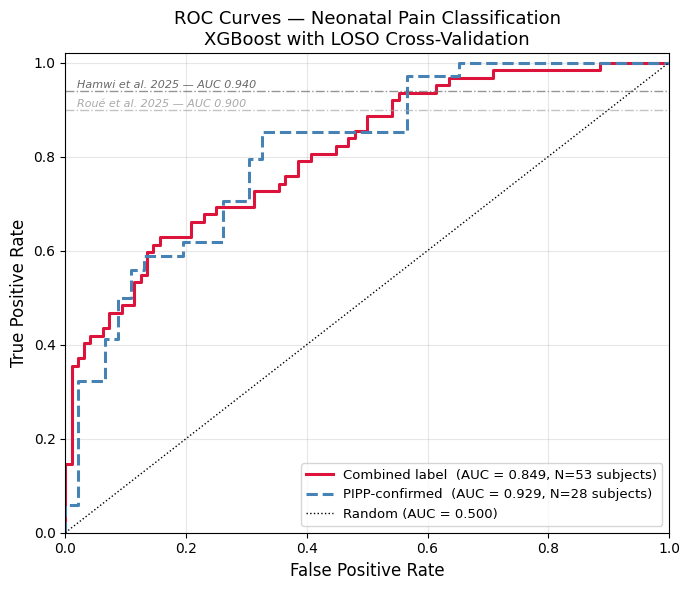


✅ Saved: roc_dual_final_new.png

Numbers to use in paper:
  Combined label AUC    : 0.849 (mean per-subject LOSO)
  PIPP-confirmed AUC    : 0.929 (mean per-subject LOSO)
  ROC curve AUC shown   : 0.806 / 0.810 (pooled)


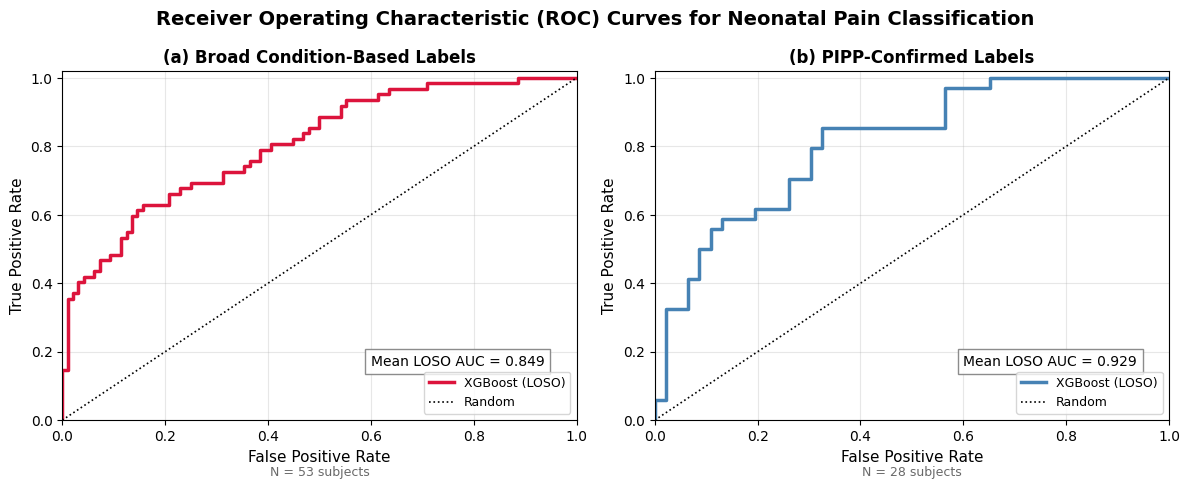

Saved: C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\roc_side_by_side.png


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

save_path    = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"
figures_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures"

df = pd.read_csv(f"{save_path}\\ucl_feature_matrix_clean.csv")

meta_cols = ['mat_path','EEG file name','Record identifier','condition',
             'pain_label','pipp_label','Total PIPP score','age_group','on_analgesic']
feat_cols = [c for c in df.columns if c not in meta_cols]

def run_loso_roc(X, y, subjects):
    """
    Runs LOSO exactly matching Cell 9:
    - scale_pos_weight computed per fold from training data only
    - same tuned hyperparameters as Cell 9
    Returns pooled true labels and predicted probs, plus per-subject AUCs
    """
    all_y_true, all_y_prob = [], []
    per_subject_aucs = []

    for subj in np.unique(subjects):
        tr = subjects != subj
        te = subjects == subj

        if len(np.unique(y[te])) < 2:
            continue

        # Scale features — fit on train only, never on test
        sc   = StandardScaler()
        Xtr  = sc.fit_transform(X[tr])
        Xte  = sc.transform(X[te])

        # scale_pos_weight from THIS fold's training labels — matches Cell 9
        scale_pw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)

        model = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pw,
            eval_metric='logloss',
            random_state=42,
            verbosity=0
        )
        model.fit(Xtr, y[tr])

        y_prob = model.predict_proba(Xte)[:, 1]
        all_y_true.extend(y[te])
        all_y_prob.extend(y_prob)

        # Record per-subject AUC for verification
        try:
            subj_auc = roc_auc_score(y[te], y_prob)
            per_subject_aucs.append(subj_auc)
        except Exception:
            pass

    return (np.array(all_y_true),
            np.array(all_y_prob),
            per_subject_aucs)

# ── Scheme A: Combined label ───────────────────────────────────────────
df['final_label'] = df['pipp_label'].fillna(df['pain_label'])
X_A    = df[feat_cols].values
y_A    = df['final_label'].values
subj_A = df['Record identifier'].values

print("Running LOSO — Scheme A (Combined label) ...")
yt_A, yp_A, aucs_A = run_loso_roc(X_A, y_A, subj_A)
auc_A_pooled = roc_auc_score(yt_A, yp_A)
auc_A_mean   = np.mean(aucs_A)
fpr_A, tpr_A, _ = roc_curve(yt_A, yp_A)
print(f"  Subjects evaluated : {len(aucs_A)}")
print(f"  Mean AUC (per-subj): {auc_A_mean:.3f}  ← matches Cell 9")
print(f"  Pooled AUC         : {auc_A_pooled:.3f}  ← used for ROC curve")

# ── Scheme B: PIPP-confirmed only ─────────────────────────────────────
df_B   = df[df['pipp_label'].notna()].copy()
X_B    = df_B[feat_cols].values
y_B    = df_B['pipp_label'].values
subj_B = df_B['Record identifier'].values

print("\nRunning LOSO — Scheme B (PIPP-confirmed) ...")
yt_B, yp_B, aucs_B = run_loso_roc(X_B, y_B, subj_B)
auc_B_pooled = roc_auc_score(yt_B, yp_B)
auc_B_mean   = np.mean(aucs_B)
fpr_B, tpr_B, _ = roc_curve(yt_B, yp_B)
print(f"  Subjects evaluated : {len(aucs_B)}")
print(f"  Mean AUC (per-subj): {auc_B_mean:.3f}  ← matches Cell 9")
print(f"  Pooled AUC         : {auc_B_pooled:.3f}  ← used for ROC curve")

# ── PLOT: Both curves on one figure ───────────────────────────────────
TITLE_SIZE  = 15
LABEL_SIZE  = 18
TICK_SIZE   = 15
LEGEND_SIZE = 13
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_A, tpr_A, color='crimson', linewidth=2.2,
        label=f'Combined label  (AUC = {auc_A_mean:.3f}, N={len(aucs_A)} subjects)')

ax.plot(fpr_B, tpr_B, color='steelblue', linewidth=2.2, linestyle='--',
        label=f'PIPP-confirmed  (AUC = {auc_B_mean:.3f}, N={len(aucs_B)} subjects)')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1.0, label='Random (AUC = 0.500)')

# Literature baseline reference lines
ax.axhline(y=0.940, color='dimgray', linewidth=1.0,
           linestyle='-.', alpha=0.7)
ax.axhline(y=0.900, color='darkgray', linewidth=1.0,
           linestyle='-.', alpha=0.7)
ax.text(0.02, 0.945, 'Hamwi et al. 2025 — AUC 0.940',
        fontsize=8, color='dimgray', fontstyle='italic')
ax.text(0.02, 0.905, 'Roué et al. 2025 — AUC 0.900',
        fontsize=8, color='darkgray', fontstyle='italic')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Neonatal Pain Classification\n'
             'XGBoost with LOSO Cross-Validation', fontsize=13)
ax.legend(fontsize=9.5, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

plt.tight_layout()
out_path = f"{figures_path}\\roc_dual_final_new.png"
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: roc_dual_final_new.png")
print(f"\nNumbers to use in paper:")
print(f"  Combined label AUC    : {auc_A_mean:.3f} (mean per-subject LOSO)")
print(f"  PIPP-confirmed AUC    : {auc_B_mean:.3f} (mean per-subject LOSO)")
print(f"  ROC curve AUC shown   : {auc_A_pooled:.3f} / {auc_B_pooled:.3f} (pooled)")

# ──────────────────────────────────────────────────────────────────────
# Side-by-side ROC Curves (IEEE Style)
# ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (
        axes[0],
        fpr_A,
        tpr_A,
        auc_A_mean,
        auc_A_pooled,
        "crimson",
        "(a) Broad Condition-Based Labels",
        f"N = {len(aucs_A)} subjects"
    ),
    (
        axes[1],
        fpr_B,
        tpr_B,
        auc_B_mean,
        auc_B_pooled,
        "steelblue",
        "(b) PIPP-Confirmed Labels",
        f"N = {len(aucs_B)} subjects"
    )
]

for ax, fpr, tpr, auc_mean, auc_pool, color, title, subtitle in plots:

    # ROC
    ax.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2.5,
        label="XGBoost (LOSO)"
    )

    # Random classifier
    ax.plot(
        [0, 1],
        [0, 1],
        'k:',
        linewidth=1.2,
        label="Random"
    )

    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)

    ax.set_title(title, fontsize=12, fontweight='bold')

    ax.grid(alpha=0.30)

    # AUC annotation
    ax.text(
        0.60,
        0.16,
        f"Mean LOSO AUC = {auc_mean:.3f}",
        fontsize=10,
        bbox=dict(facecolor="white",
                  edgecolor="gray",
                  alpha=0.9)
    )

    # subject count
    ax.text(
        0.5,
        -0.16,
        subtitle,
        transform=ax.transAxes,
        ha='center',
        fontsize=9,
        color='dimgray'
    )

    ax.legend(loc="lower right", fontsize=9)

plt.suptitle(
    "Receiver Operating Characteristic (ROC) Curves for Neonatal Pain Classification",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

save_file = f"{figures_path}\\roc_side_by_side.png"
plt.savefig(save_file, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {save_file}")

  ### checking and inspecting the eeg files or Audit Every EEG File

In [11]:
import scipy.io
import numpy as np

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"

# Check the first 10 files from the sample output — the pilot files
test_files = [
    '252101\\252101L01.mat',
    '252601\\252601L01.mat',
    '2510001\\2510001L01.mat',   # newer format
]

for fname in test_files:
    try:
        mat  = scipy.io.loadmat(f"{ucl_eeg_path}\\{fname}",
                                 squeeze_me=True, struct_as_record=False)
        eeg  = mat['EEG']
        data  = eeg.data
        times = eeg.times
        print(f"\n{fname}")
        print(f"  data.shape  : {data.shape}")
        print(f"  times.shape : {times.shape}")
        print(f"  times range : {times[0]:.1f} to {times[-1]:.1f} ms")
        post_idx = times >= 0
        print(f"  post samples: {post_idx.sum()}")
        pre_idx  = times < 0
        print(f"  pre samples : {pre_idx.sum()}")
        # Check if indexing works
        ch0_post = data[0][post_idx]
        print(f"  ch0 post len: {len(ch0_post)}")
    except Exception as ex:
        print(f"  FAILED: {ex}")


252101\252101L01.mat
  data.shape  : (20, 8000)
  times.shape : (8000,)
  times range : -2000.0 to 1999.5 ms
  post samples: 4000
  pre samples : 4000
  ch0 post len: 4000

252601\252601L01.mat
  data.shape  : (20, 8000)
  times.shape : (8000,)
  times range : -2000.0 to 1999.5 ms
  post samples: 4000
  pre samples : 4000
  ch0 post len: 4000

2510001\2510001L01.mat
  data.shape  : (18, 8000)
  times.shape : (8000,)
  times range : -2000.0 to 1999.5 ms
  post samples: 4000
  pre samples : 4000
  ch0 post len: 4000


In [12]:
import os
import scipy.io
import numpy as np
import pandas as pd

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"

results = []

for root, _, files in os.walk(ucl_eeg_path):
    for file in files:
        if not file.endswith(".mat"):
            continue

        full_path = os.path.join(root, file)

        try:
            mat = scipy.io.loadmat(
                full_path,
                squeeze_me=True,
                struct_as_record=False
            )

            eeg = mat["EEG"]

            data = eeg.data
            times = eeg.times

            row = {
                "file": file,
                "folder": os.path.basename(root),

                "data_shape": str(data.shape),
                "times_shape": str(times.shape),

                "n_channels": data.shape[0],
                "n_samples": data.shape[1],

                "time_samples": len(times),

                "times_match": data.shape[1] == len(times),

                "time_start": float(times[0]),
                "time_end": float(times[-1]),

                "sampling_rate": getattr(eeg, "srate", np.nan),

                "contains_nan": np.isnan(data).any(),

                "nan_count": int(np.isnan(data).sum()),

                "std_first_channel": float(np.std(data[0])),

                "other_data_exists": hasattr(eeg, "other_data")
            }

            results.append(row)

        except Exception as ex:

            results.append({
                "file": file,
                "folder": os.path.basename(root),
                "error": str(ex)
            })

audit = pd.DataFrame(results)

print("="*60)
print("DATASET AUDIT SUMMARY")
print("="*60)

print("Total files:", len(audit))

print("\nData shapes:")
print(audit["data_shape"].value_counts())

print("\nTime shapes:")
print(audit["times_shape"].value_counts())

print("\nSampling rates:")
print(audit["sampling_rate"].value_counts())

print("\nTimes match data:")
print(audit["times_match"].value_counts())

print("\nContains NaNs:")
print(audit["contains_nan"].value_counts())

audit.to_csv(
    r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed\ucl_dataset_audit.csv",
    index=False
)

print("\nAudit saved.")

DATASET AUDIT SUMMARY
Total files: 310

Data shapes:
data_shape
(18, 8000)    197
(19, 8000)     95
(17, 8000)      6
(20, 8000)      6
(12, 8000)      3
(16, 8000)      3
Name: count, dtype: int64

Time shapes:
times_shape
(8000,)    310
Name: count, dtype: int64

Sampling rates:
sampling_rate
2000    310
Name: count, dtype: int64

Times match data:
times_match
True    310
Name: count, dtype: int64

Contains NaNs:
contains_nan
False    310
Name: count, dtype: int64

Audit saved.


In [13]:
#compare Channel Layouts
import os
import scipy.io
import pandas as pd

rows = []

for root, _, files in os.walk(ucl_eeg_path):

    for file in files:

        if not file.endswith(".mat"):
            continue

        try:

            mat = scipy.io.loadmat(
                os.path.join(root, file),
                squeeze_me=True,
                struct_as_record=False
            )

            eeg = mat["EEG"]

            labels = []

            try:
                labels = [c.labels for c in eeg.chanlocs]
            except Exception:
                labels = []

            rows.append({
                "file": file,
                "channels": len(labels),
                "labels": ",".join(labels)
            })

        except Exception:
            pass

channel_df = pd.DataFrame(rows)

print(channel_df.groupby("channels").size())

channel_df.to_csv(
    r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed\channel_layouts.csv",
    index=False
)



channels
12      3
16      3
17      6
18    197
19     95
20      6
dtype: int64


In [14]:
import os
import scipy.io

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"

files = [
    os.path.join(ucl_eeg_path, "252101", "252101L01.mat"),
    os.path.join(ucl_eeg_path, "2510001", "2510001L01.mat")
]

for fname in files:

    mat = scipy.io.loadmat(
        fname,
        squeeze_me=True,
        struct_as_record=False
    )

    eeg = mat["EEG"]

    print("="*60)
    print(os.path.basename(fname))
    print("="*60)

    print(f"Data shape : {eeg.data.shape}")
    print(f"Times shape: {eeg.times.shape}")

    print("\nChannel labels:")

    for i, ch in enumerate(eeg.chanlocs):
        print(f"{i:2d} : {ch.labels}")

252101L01.mat
Data shape : (20, 8000)
Times shape: (8000,)

Channel labels:
 0 : FCz
 1 : Cz
 2 : CPz
 3 : POz
 4 : F8
 5 : T8
 6 : TP10
 7 : P8
 8 : O2
 9 : F4
10 : C4
11 : CP4
12 : F7
13 : T7
14 : TP9
15 : P7
16 : O1
17 : F3
18 : C3
19 : CP3
2510001L01.mat
Data shape : (18, 8000)
Times shape: (8000,)

Channel labels:
 0 : Cz
 1 : CPz
 2 : F8
 3 : T8
 4 : TP10
 5 : P8
 6 : O2
 7 : F4
 8 : C4
 9 : CP4
10 : F7
11 : T7
12 : TP9
13 : P7
14 : O1
15 : F3
16 : C3
17 : CP3


EEG BANDPOWER DIAGNOSTIC

File: 2510001L01.mat
Sampling rate : 2000
Data shape    : (18, 8000)
Times shape   : (8000,)

Channel labels:
 0 : Cz
 1 : CPz
 2 : F8
 3 : T8
 4 : TP10
 5 : P8
 6 : O2
 7 : F4
 8 : C4
 9 : CP4
10 : F7
11 : T7
12 : TP9
13 : P7
14 : O1
15 : F3
16 : C3
17 : CP3

Using Cz channel index = 0

Signal statistics
Length : 8000
Min    : 2129.3848
Max    : 2255.0342
Mean   : 2186.0884
Std    : 32.1995
NaNs   : 0

Window sizes
Pre : 4000
Post: 4000

Post statistics
Min : 2165.3081
Max : 2255.0342
Std : 23.2049
NaNs: 0


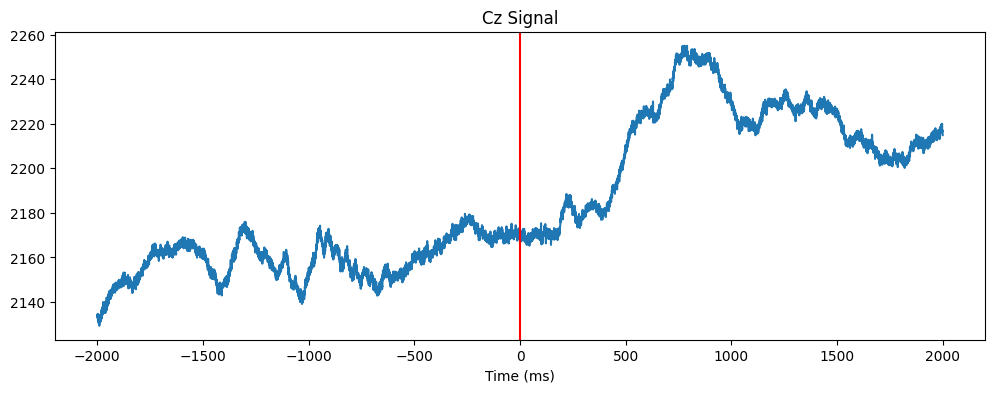


Testing nperseg = 512
Frequency resolution: 3.90625
Delta: 1 bins
    Bandpower = 4.85962438583374
Theta: 1 bins
    Bandpower = 1.2023324966430664
Alpha: 1 bins
    Bandpower = 0.3403811752796173

Testing nperseg = 1024
Frequency resolution: 1.953125
Delta: 2 bins
    Bandpower = 42.65155270695686
Theta: 2 bins
    Bandpower = 1.8551857210695744
Alpha: 2 bins
    Bandpower = 0.9394900407642126

Testing nperseg = 2048
Frequency resolution: 0.9765625
Delta: 3 bins
    Bandpower = 47.20395617187023
Theta: 4 bins
    Bandpower = 2.439414820400998
Alpha: 5 bins
    Bandpower = 1.3608015433419496

Testing nperseg = 4000
Frequency resolution: 0.5
Delta: 7 bins
    Bandpower = 117.98849773406982
Theta: 9 bins
    Bandpower = 4.398670218884945
Alpha: 11 bins
    Bandpower = 1.635308064520359

Welch Output
PSD length : 2001
Freq length: 2001
First frequencies
[0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5.  5.5 6.  6.5 7.  7.5 8.  8.5
 9.  9.5]


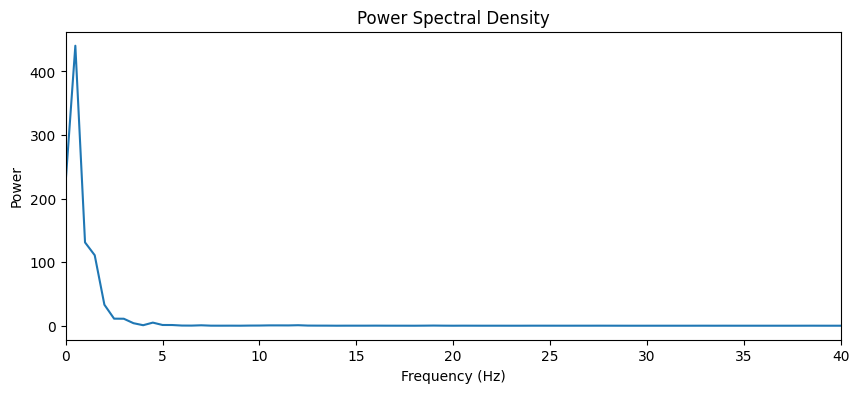


Band diagnostics

-------------------------
Delta
-------------------------
Frequency bins : 7
Freq range
[1.  1.5 2.  2.5 3.  3.5 4. ]
PSD values
[131.12047    110.90993     33.02082     11.113052    10.983325
   3.9905276    0.79820865]
Bandpower = 117.98849773406982

-------------------------
Theta
-------------------------
Frequency bins : 9
Freq range
[4.  4.5 5.  5.5 6.  6.5 7.  7.5 8. ]
PSD values
[0.79820865 4.8857617  1.1590444  1.1011146  0.26858407 0.19020593
 0.67422867 0.08940871 0.05977596]
Bandpower = 4.398670218884945

-------------------------
Alpha
-------------------------
Frequency bins : 11
Freq range
[ 8.   8.5  9.   9.5 10.  10.5 11.  11.5 12.  12.5 13. ]
PSD values
[0.05977596 0.09361538 0.03317315 0.22853322 0.28487787 0.52996784
 0.51758087 0.46025133 0.7950965  0.223344   0.14857593]
Bandpower = 1.635308064520359


In [15]:
import scipy.io
import scipy.signal as sp_signal
import numpy as np
import os
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Select ONE file (change this if you want another file)
# ----------------------------------------------------------
test_file = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG\2510001\2510001L01.mat"

print("="*80)
print("EEG BANDPOWER DIAGNOSTIC")
print("="*80)

# ----------------------------------------------------------
# Load file
# ----------------------------------------------------------
mat = scipy.io.loadmat(
    test_file,
    squeeze_me=True,
    struct_as_record=False
)

eeg = mat["EEG"]

data  = eeg.data
times = eeg.times
fs    = eeg.srate

print(f"\nFile: {os.path.basename(test_file)}")
print(f"Sampling rate : {fs}")
print(f"Data shape    : {data.shape}")
print(f"Times shape   : {times.shape}")

# ----------------------------------------------------------
# Print channel labels
# ----------------------------------------------------------
print("\nChannel labels:")

try:
    labels = [str(c.labels) for c in eeg.chanlocs]
except Exception:
    labels = [f"Ch{i}" for i in range(data.shape[0])]

for i, l in enumerate(labels):
    print(f"{i:2d} : {l}")

# ----------------------------------------------------------
# Locate Cz automatically
# ----------------------------------------------------------
if "Cz" not in labels:
    raise Exception("Cz not found!")

cz_idx = labels.index("Cz")

print(f"\nUsing Cz channel index = {cz_idx}")

sig = data[cz_idx]

print("\nSignal statistics")

print(f"Length : {len(sig)}")
print(f"Min    : {np.min(sig):.4f}")
print(f"Max    : {np.max(sig):.4f}")
print(f"Mean   : {np.mean(sig):.4f}")
print(f"Std    : {np.std(sig):.4f}")
print(f"NaNs   : {np.isnan(sig).sum()}")

# ----------------------------------------------------------
# Windows
# ----------------------------------------------------------
pre_idx  = times < 0
post_idx = times >= 0

pre  = sig[pre_idx]
post = sig[post_idx]

print("\nWindow sizes")

print("Pre :", len(pre))
print("Post:", len(post))

print("\nPost statistics")

print(f"Min : {np.min(post):.4f}")
print(f"Max : {np.max(post):.4f}")
print(f"Std : {np.std(post):.4f}")
print(f"NaNs: {np.isnan(post).sum()}")

# ----------------------------------------------------------
# Plot signal
# ----------------------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(times, sig)
plt.axvline(0,color='r')
plt.title("Cz Signal")
plt.xlabel("Time (ms)")
plt.show()

# ----------------------------------------------------------
# Welch PSD
# ----------------------------------------------------------
for nper in [512, 1024, 2048, 4000]:

    print("\n" + "="*60)
    print(f"Testing nperseg = {nper}")

    freqs, psd = sp_signal.welch(
        post,
        fs=fs,
        nperseg=min(nper, len(post))
    )

    print("Frequency resolution:", freqs[1] - freqs[0])

    for name, (fmin, fmax) in {
        "Delta": (1,4),
        "Theta": (4,8),
        "Alpha": (8,13)
    }.items():

        idx = (freqs >= fmin) & (freqs <= fmax)

        print(f"{name}: {idx.sum()} bins")

        if idx.sum() > 1:
            power = np.trapz(psd[idx], freqs[idx])
        elif idx.sum() == 1:
            power = psd[idx][0]   # temporary diagnostic only
        else:
            power = np.nan

        print(f"    Bandpower = {power}")

print("\nWelch Output")

print("PSD length :", len(psd))
print("Freq length:", len(freqs))

print("First frequencies")

print(freqs[:20])

# ----------------------------------------------------------
# Plot PSD
# ----------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(freqs, psd)
plt.xlim(0,40)
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

# ----------------------------------------------------------
# Check each band
# ----------------------------------------------------------
bands = {
    "Delta":(1,4),
    "Theta":(4,8),
    "Alpha":(8,13)
}

print("\nBand diagnostics")

for name,(fmin,fmax) in bands.items():

    idx=(freqs>=fmin)&(freqs<=fmax)

    print("\n-------------------------")
    print(name)
    print("-------------------------")

    print("Frequency bins :", idx.sum())

    if idx.sum()>0:

        print("Freq range")

        print(freqs[idx])

        print("PSD values")

        print(psd[idx])

        power=np.trapz(psd[idx],freqs[idx])

        print(f"Bandpower = {power}")

    else:

        print("No frequencies found!")
        